In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import tensorflow as tf 
import re 
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
import seaborn as sns 
plt.style.use('ggplot')

In [2]:
#Read the data
fake_df = pd.read_csv(r'D:\Backup 14.03.2021\Desktop\Imarticus Post\Online PGA 32\DL & AI\Project on RNN\Dataset\Fake.csv')
real_df = pd.read_csv(r'D:\Backup 14.03.2021\Desktop\Imarticus Post\Online PGA 32\DL & AI\Project on RNN\Dataset\True.csv')

In [3]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
real_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
#Checking for null values
fake_df.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [6]:
real_df.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [7]:
fake_df.shape

(23481, 4)

In [8]:
real_df.shape

(21417, 4)

In [9]:
#Checking for unique values for subject. We want both data frames to have a similar distribution.
fake_df.subject.unique()

array(['News', 'politics', 'Government News', 'left-news', 'US_News',
       'Middle-east'], dtype=object)

In [10]:
real_df.subject.unique()

array(['politicsNews', 'worldnews'], dtype=object)

In [11]:
#Drop the date from the dataset, I don't think there is a strong correlation between date and validity of the news. As we see above, subjects are not
#distributed evenly. We do not want that to influence the accuracy of our classifier. Therefore, we need to drop that as well.
fake_df.drop(['date', 'subject'], axis=1, inplace=True)
real_df.drop(['date', 'subject'], axis=1, inplace=True)

In [13]:
#0 for fake news, and 1 for real news
fake_df['class'] = 0 
real_df['class'] = 1

In [14]:
len(fake_df)

23481

In [15]:
len(real_df)

21417

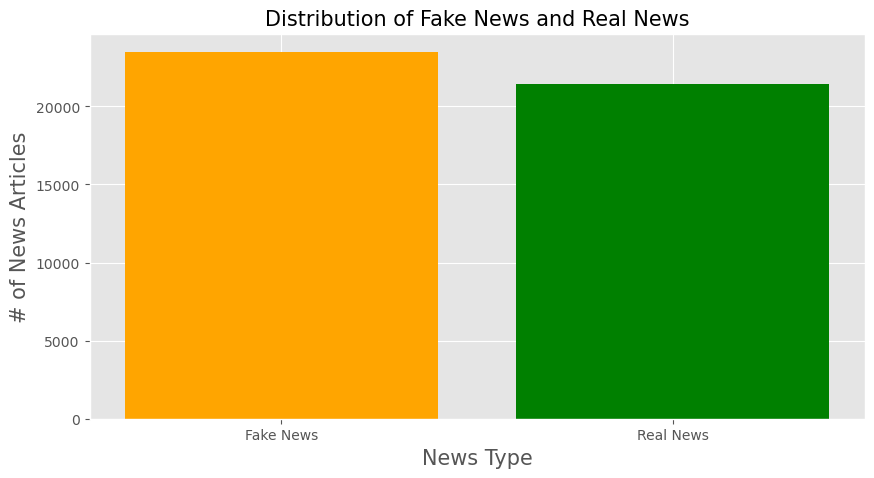

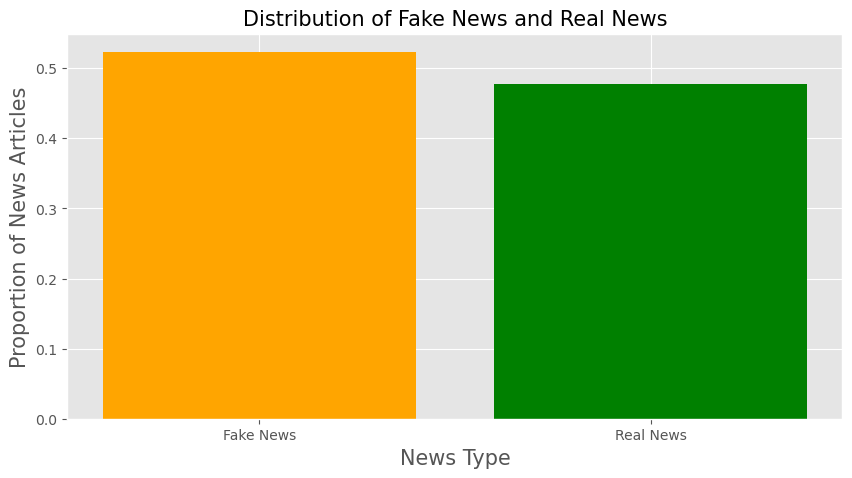

In [16]:
#Check out the distribution of fake news compare to real news
plt.figure(figsize=(10, 5))
plt.bar('Fake News', len(fake_df), color='orange')
plt.bar('Real News', len(real_df), color='green')
plt.title('Distribution of Fake News and Real News', size=15)
plt.xlabel('News Type', size=15)
plt.ylabel('# of News Articles', size=15)


total_len = len(fake_df) + len(real_df)
plt.figure(figsize=(10, 5))
plt.bar('Fake News', len(fake_df) / total_len, color='orange')
#plt.text(x, y, s=)
plt.bar('Real News', len(real_df) / total_len, color='green')
#plt.text(x, y, s=)
plt.title('Distribution of Fake News and Real News', size=15)
plt.xlabel('News Type', size=15)
plt.ylabel('Proportion of News Articles', size=15)
plt.show()

In [17]:
print('Difference in news articles:',len(fake_df)-len(real_df))

Difference in news articles: 2064


In [18]:
news_df = pd.concat([fake_df, real_df], ignore_index=True, sort=False)
news_df

,title,text,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0
...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,1
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",1
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,1
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,1


In [19]:
#Combining the title with the text, it is much easier to process this way.
news_df['text'] = news_df['title'] + news_df['text']
news_df.drop('title', axis=1, inplace=True)

In [20]:
#Split into training and testing
features = news_df['text']
targets = news_df['class']

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.20, random_state=18)

In [21]:
X_train.shape

(35918,)

In [22]:
#Normalizing our data: lower case, get rid of extra spaces, and url links.
def normalize(data):
    normalized = []
    for i in data:
        i = i.lower()
        # get rid of urls
        i = re.sub('https?://\S+|www\.\S+', '', i)
        # get rid of non words and extra spaces
        i = re.sub('\\W', ' ', i)
        i = re.sub('\n', '', i)
        i = re.sub(' +', ' ', i)
        i = re.sub('^ ', '', i)
        i = re.sub(' $', '', i)
        normalized.append(i)
    return normalized

X_train = normalize(X_train)
X_test = normalize(X_test)

In [23]:
max_vocab = 10000
tokenizer = Tokenizer(num_words=max_vocab)
tokenizer.fit_on_texts(X_train)

#fit_on_texts Updates internal vocabulary based on a list of texts. This method creates the vocabulary index based on word frequency

In [24]:
#Convert text to vectors, our classifier only takes numerical data.
# tokenize the text into vectors 
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)
#texts_to_sequences transforms each text in texts in a sequence of integers


In [25]:
#Apply padding so we have the same length for each article
X_train = tf.keras.preprocessing.sequence.pad_sequences(X_train, padding='post', maxlen=256)
X_test = tf.keras.preprocessing.sequence.pad_sequences(X_test, padding='post', maxlen=256)
#pad_sequence stacks a list of Tensors along a new dimension, and pads them to equal length

In [26]:
print(X_train.shape)
print(X_test.shape)

(35918, 256)
(8980, 256)


In [27]:
#Building the RNN.
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_vocab, 128), #Keras provides an embedding layer that converts each word into a fixed-length vector of defined size
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,  return_sequences=True)), #Bidirectional recurrent layers are defined as connecting
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16)),                         # two hidden layers of the opposite directions to same output
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5), #The Dropout layer randomly sets input units to 0 with a frequency of rate at each step during training time, which helps prevent overfitting
    tf.keras.layers.Dense(1)
])

In [28]:
#We are going to use early stop, which stops when the validation loss no longer improve.
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10,validation_split=0.1, batch_size=30, shuffle=True, callbacks=[early_stop])

Epoch 1/10
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 532s 462ms/step - accuracy: 0.7485 - loss: 0.4434 - val_accuracy: 0.9694 - val_loss: 0.0814
Epoch 2/10
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 494s 458ms/step - accuracy: 0.9850 - loss: 0.0530 - val_accuracy: 0.9891 - val_loss: 0.0304
Epoch 3/10
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 502s 466ms/step - accuracy: 0.9947 - loss: 0.0214 - val_accuracy: 0.9903 - val_loss: 0.0370
Epoch 4/10
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 510s 473ms/step - accuracy: 0.9955 - loss: 0.0171 - val_accuracy: 0.9883 - val_loss: 0.0348


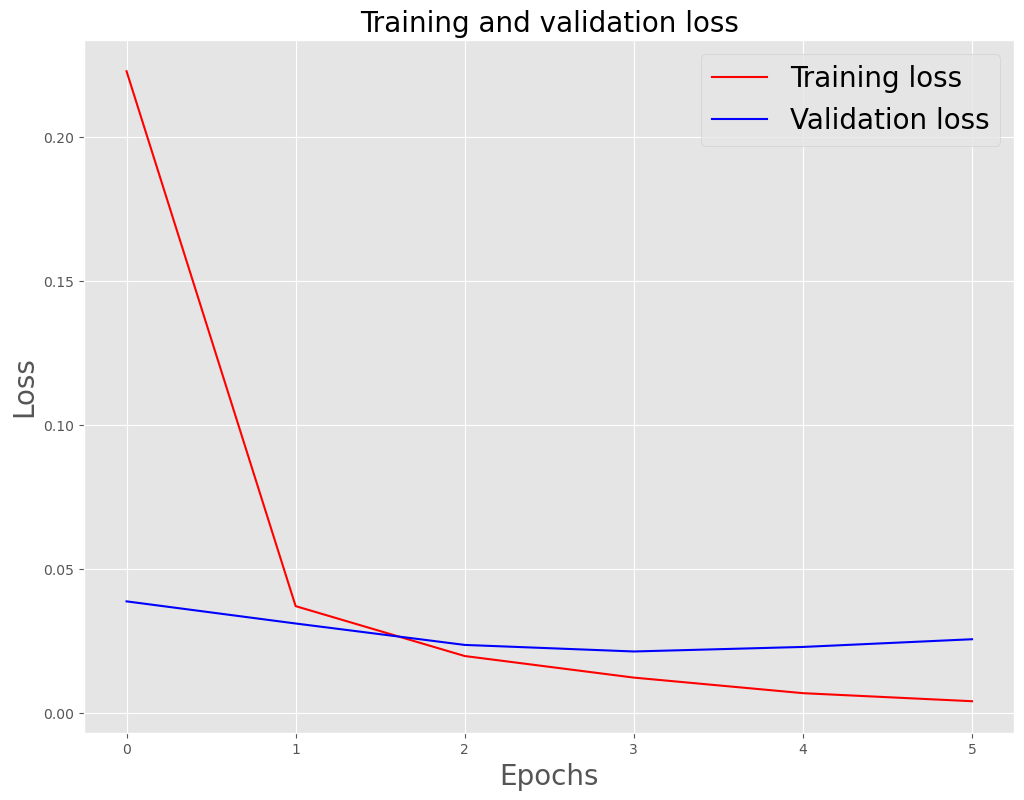

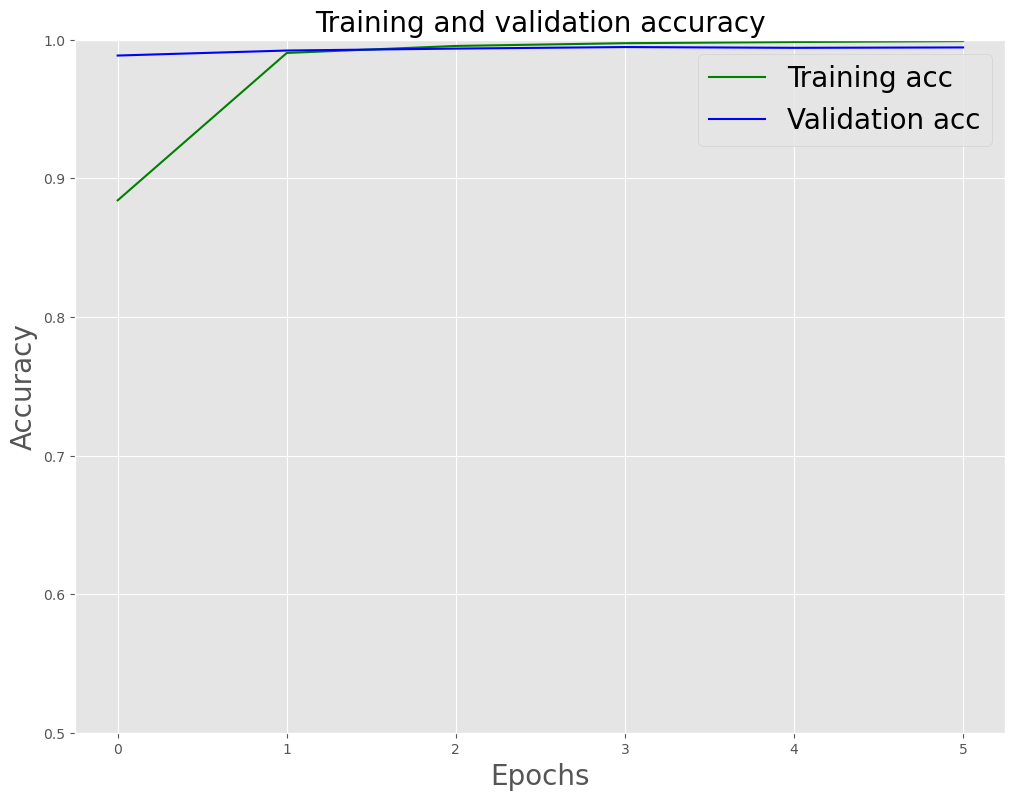

In [30]:
#Visualize our training over time
history_dict = history.history #history field is a dictionary which helds different training metrics spanned across every training epoch

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = history.epoch

plt.figure(figsize=(12,9))
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss', size=20)
plt.xlabel('Epochs', size=20)
plt.ylabel('Loss', size=20)
plt.legend(prop={'size': 20})
plt.show()

plt.figure(figsize=(12,9))
plt.plot(epochs, acc, 'g', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy', size=20)
plt.xlabel('Epochs', size=20)
plt.ylabel('Accuracy', size=20)
plt.legend(prop={'size': 20})
plt.ylim(0.5,1)
plt.show()

In [31]:
#Evaluate the testing set
model.evaluate(X_test, y_test)

281/281 ━━━━━━━━━━━━━━━━━━━━ 42s 149ms/step - accuracy: 0.9918 - loss: 0.0307


[0.026831557974219322, 0.9927616715431213]

In [32]:
pred = model.predict(X_test)

binary_predictions = []

for i in pred:
    if i >= 0.5:
        binary_predictions.append(1)
    else:
        binary_predictions.append(0) 

281/281 ━━━━━━━━━━━━━━━━━━━━ 48s 161ms/step


In [33]:
print('Accuracy on testing set:', accuracy_score(binary_predictions, y_test))
print('Precision on testing set:', precision_score(binary_predictions, y_test))
print('Recall on testing set:', recall_score(binary_predictions, y_test))

Accuracy on testing set: 0.9927616926503341
Precision on testing set: 0.99235757295044
Recall on testing set: 0.9925874449849432


[Text(0, 0.5, '0'), Text(0, 1.5, '1')]

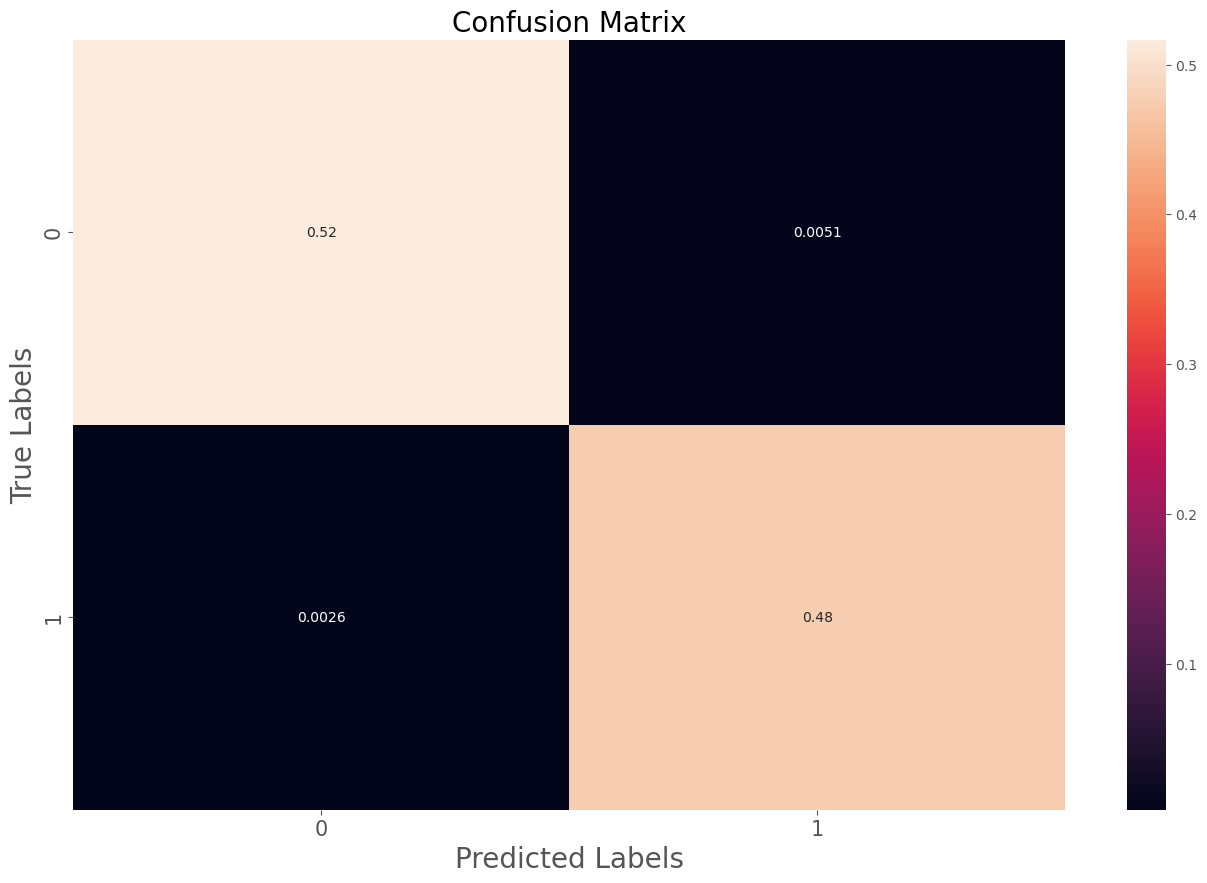

In [34]:
#Confusion matrix
matrix = confusion_matrix(binary_predictions, y_test, normalize='all')
plt.figure(figsize=(16, 10))
ax= plt.subplot()
sns.heatmap(matrix, annot=True, ax = ax)

# labels, title and ticks
ax.set_xlabel('Predicted Labels', size=20)
ax.set_ylabel('True Labels', size=20)
ax.set_title('Confusion Matrix', size=20) 
ax.xaxis.set_ticklabels([0,1], size=15)
ax.yaxis.set_ticklabels([0,1], size=15)